In [1]:
!pip install pandas numpy scikit-learn nltk matplotlib seaborn

import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import PassiveAggressiveClassifier, LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, ConfusionMatrixDisplay
)
nltk.download('stopwords')
print("All libraries imported successfully.")


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\inbox\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.


All libraries imported successfully.


In [2]:
# Load Fake and Real news CSVs
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

# Assign labels: 0 = Fake, 1 = Real
fake["label"] = 0
true["label"] = 1

# Combine and shuffle
data = pd.concat([fake, true], axis=0)
data = data.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Total articles: {len(data)}")
print(f"Fake articles : {len(fake)}")
print(f"Real articles : {len(true)}")
data.head()

Total articles: 44898
Fake articles : 23481
Real articles : 21417


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",0
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",1
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",1
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",0
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",1


C:\Users\inbox\AppData\Local\Temp\ipykernel_30660\3016349788.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=data, palette='coolwarm')


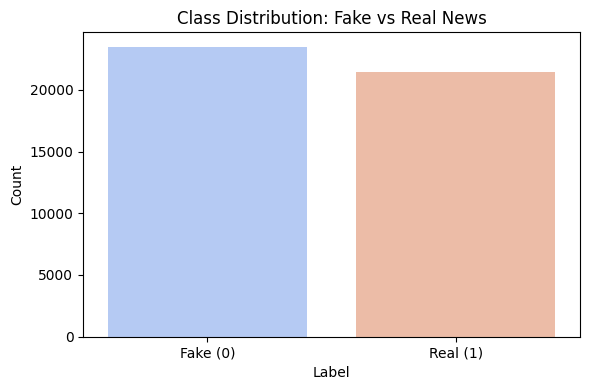

C:\Users\inbox\AppData\Local\Temp\ipykernel_30660\3016349788.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='subject', data=data, order=data['subject'].value_counts().index, palette='viridis')


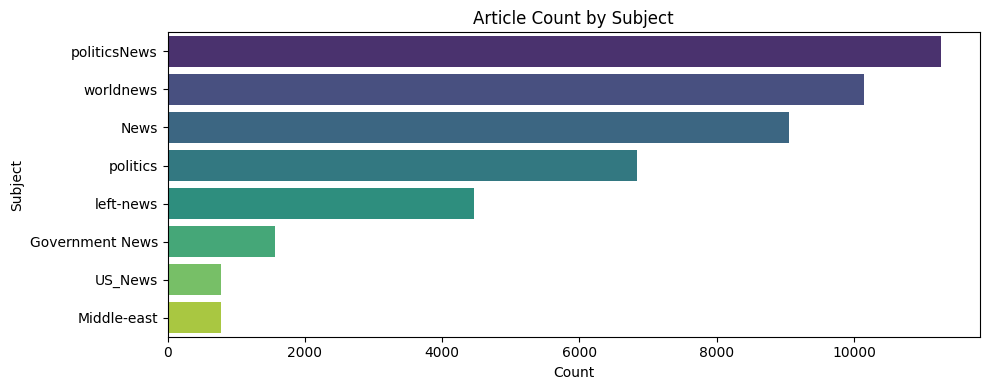

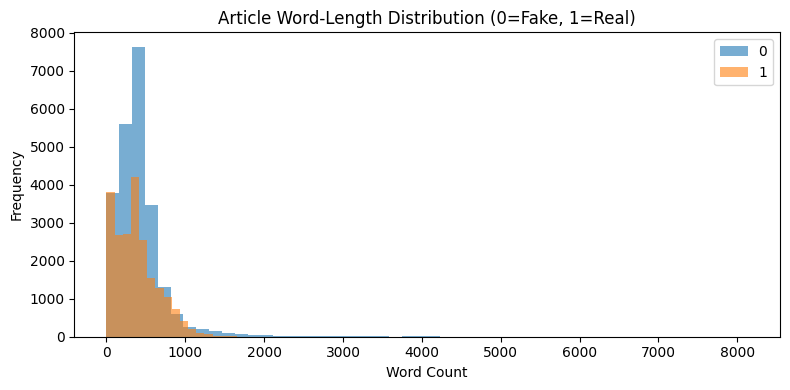


Average article length by label:
label
0    423.197905
1    385.640099
Name: text_length, dtype: float64


In [3]:
# 3a. Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=data, palette='coolwarm')
plt.title("Class Distribution: Fake vs Real News")
plt.xticks([0, 1], ['Fake (0)', 'Real (1)'])
plt.xlabel("Label")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

# 3b. Subject Distribution
plt.figure(figsize=(10, 4))
sns.countplot(y='subject', data=data, order=data['subject'].value_counts().index, palette='viridis')
plt.title("Article Count by Subject")
plt.xlabel("Count")
plt.ylabel("Subject")
plt.tight_layout()
plt.show()

# 3c. Article text length distribution
data['text_length'] = data['text'].apply(lambda x: len(str(x).split()))
plt.figure(figsize=(8, 4))
data.groupby('label')['text_length'].plot(kind='hist', bins=50, alpha=0.6, legend=True)
plt.title("Article Word-Length Distribution (0=Fake, 1=Real)")
plt.xlabel("Word Count")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print("\nAverage article length by label:")
print(data.groupby('label')['text_length'].mean())

In [4]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # Step 1: Lowercase
    text = text.lower()
    # Step 2: Remove non-alphabetic characters (tokenization)
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    # Step 3: Split into words
    words = text.split()
    # Step 4: Remove stop words
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

# Combine title + text, then preprocess
data["content"] = data["title"] + " " + data["text"]
data["clean_text"] = data["content"].apply(preprocess_text)

print("Preprocessing complete.")
print("\nSample cleaned text:")
print(data["clean_text"].iloc[0][:300])

Preprocessing complete.

Sample cleaned text:
ben stein calls th circuit court committed coup tat constitution st century wire says ben stein reputable professor pepperdine university also hollywood fame appearing tv shows films ferris bueller day made provocative statements judge jeanine pirro show recently discussing halt imposed president tr


In [7]:
#Splitting the dataset into 80% training and 20% testing sets.

X = data["clean_text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print(f"Training samples : {len(X_train)}")
print(f"Testing samples  : {len(X_test)}")
print(f"Total articles : {len(data)}")
print(f"Fake articles  : {len(fake)}")
print(f"Real articles  : {len(true)}")

Training samples : 35918
Testing samples  : 8980
Total articles : 44898
Fake articles  : 23481
Real articles  : 21417


In [8]:
tfidf = TfidfVectorizer(max_df=0.7)

# Fit on training data only, transform both
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"TF-IDF vocabulary size : {len(tfidf.vocabulary_)}")
print(f"Training matrix shape  : {X_train_tfidf.shape}")
print(f"Testing matrix shape   : {X_test_tfidf.shape}")

TF-IDF vocabulary size : 105976
Training matrix shape  : (35918, 105976)
Testing matrix shape   : (8980, 105976)


In [10]:
pac_model = PassiveAggressiveClassifier(max_iter=50, random_state=42)
pac_model.fit(X_train_tfidf, y_train)

y_pred_pac = pac_model.predict(X_test_tfidf)

print("PAC model trained and predictions generated.")

PAC model trained and predictions generated.


In [11]:
#Evaluating the proposed model using all four metrics mentioned in the abstract.

accuracy  = accuracy_score(y_test, y_pred_pac)
precision = precision_score(y_test, y_pred_pac)
recall    = recall_score(y_test, y_pred_pac)
f1        = f1_score(y_test, y_pred_pac)

print("=== Passive Aggressive Classifier Results ===")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_pac, target_names=['Fake', 'Real']))

=== Passive Aggressive Classifier Results ===
Accuracy  : 0.9944
Precision : 0.9932
Recall    : 0.9951
F1 Score  : 0.9942

Detailed Classification Report:
              precision    recall  f1-score   support

        Fake       1.00      0.99      0.99      4710
        Real       0.99      1.00      0.99      4270

    accuracy                           0.99      8980
   macro avg       0.99      0.99      0.99      8980
weighted avg       0.99      0.99      0.99      8980



---
## Step 9: Confusion Matrix — PAC
Visualizing true vs predicted classifications.

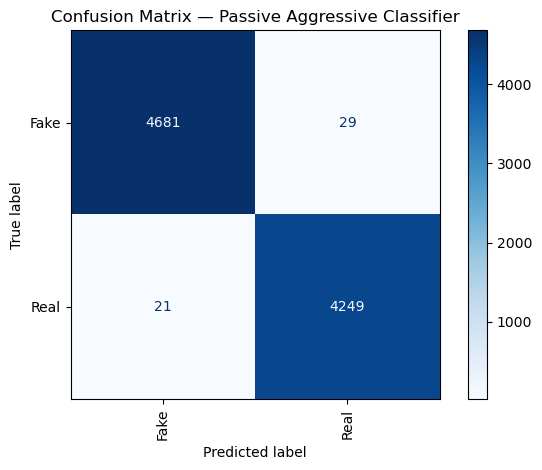

In [9]:
disp = ConfusionMatrixDisplay.from_estimator(
    pac_model,
    X_test_tfidf,
    y_test,
    display_labels=['Fake', 'Real'],
    cmap=plt.cm.Blues,
    xticks_rotation='vertical'
)
plt.title("Confusion Matrix — Passive Aggressive Classifier")
plt.tight_layout()
plt.show()

---
## Step 10: Baseline Comparisons
Comparing the PAC against conventional baseline classifiers: Logistic Regression, Naive Bayes, and Linear SVM.
This directly supports the abstract's claim of "competitive results when compared to conventional baseline classifiers."

In [10]:
baselines = {
    "Logistic Regression" : LogisticRegression(max_iter=1000, random_state=42),
    "Naive Bayes"         : MultinomialNB(),
    "Linear SVM"          : LinearSVC(max_iter=1000, random_state=42),
    "Passive Aggressive"  : PassiveAggressiveClassifier(max_iter=50, random_state=42),
}

results = []

for name, model in baselines.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results.append({
        "Model"     : name,
        "Accuracy"  : round(accuracy_score(y_test, y_pred), 4),
        "Precision" : round(precision_score(y_test, y_pred), 4),
        "Recall"    : round(recall_score(y_test, y_pred), 4),
        "F1 Score"  : round(f1_score(y_test, y_pred), 4),
    })

results_df = pd.DataFrame(results).set_index("Model")
print("=== Baseline Comparison ===")
print(results_df.to_string())

C:\Users\hp\AppData\Roaming\Python\Python311\site-packages\sklearn\svm\_classes.py:31: FutureWarning: The default value of `dual` will change from `True` to `'auto'` in 1.5. Set the value of `dual` explicitly to suppress the warning.
  warnings.warn(


=== Baseline Comparison ===
                     Accuracy  Precision  Recall  F1 Score
Model                                                     
Logistic Regression    0.9853     0.9816  0.9876    0.9846
Naive Bayes            0.9346     0.9369  0.9248    0.9308
Linear SVM             0.9949     0.9937  0.9956    0.9946
Passive Aggressive     0.9944     0.9932  0.9951    0.9942


---
## Step 11: Visualize Baseline Comparison
Bar chart comparing all four models across all four metrics.

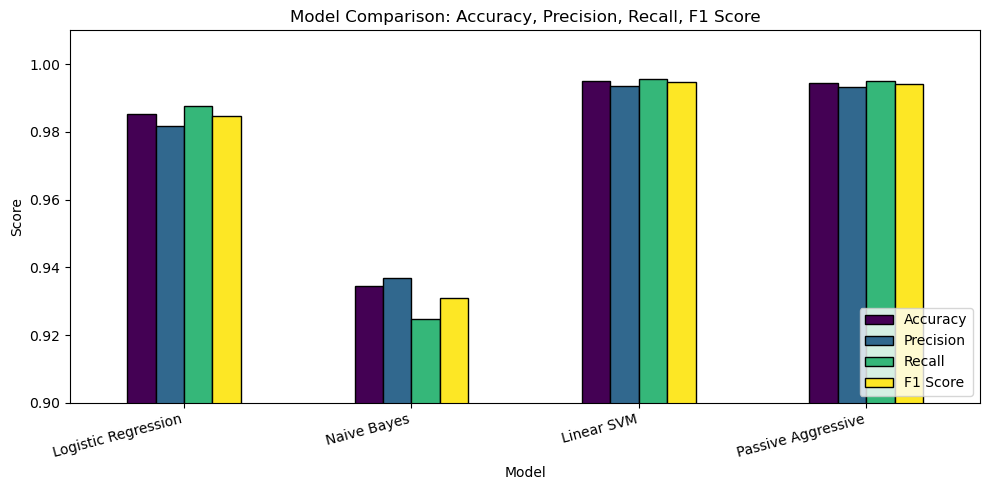

In [11]:
ax = results_df.plot(
    kind='bar',
    figsize=(10, 5),
    colormap='viridis',
    ylim=(0.9, 1.01),
    edgecolor='black'
)
plt.title("Model Comparison: Accuracy, Precision, Recall, F1 Score")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=15, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

---
## Step 12: Cross-Validation (5-Fold) on PAC
Validating that the PAC's performance is stable and not due to a lucky train/test split.

In [12]:
from sklearn.pipeline import Pipeline

# Build a pipeline so CV handles vectorization properly
pac_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_df=0.7)),
    ('clf',   PassiveAggressiveClassifier(max_iter=50, random_state=42))
])

cv_scores = cross_val_score(pac_pipeline, X, y, cv=5, scoring='accuracy')

print("=== 5-Fold Cross-Validation (PAC) ===")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean Accuracy : {cv_scores.mean():.4f}")
print(f"  Std Deviation : {cv_scores.std():.4f}")

=== 5-Fold Cross-Validation (PAC) ===
  Fold 1: 0.9955
  Fold 2: 0.9955
  Fold 3: 0.9960
  Fold 4: 0.9960
  Fold 5: 0.9960

  Mean Accuracy : 0.9958
  Std Deviation : 0.0002
